# BÁO CÁO BÀI TẬP LỚN: DỰ ĐOÁN GIÁ NHÀ CALIFORNIA BẰNG MÔ HÌNH HỒI QUY

Notebook xây dựng quy trình phân tích và dự đoán giá nhà trên bộ dữ liệu **California Housing**. Biến mục tiêu là `MedHouseVal`; hai mô hình được so sánh gồm **Linear Regression** và **Gradient Boosting Regressor**.

## Mục lục

1. [Chuẩn bị môi trường và thư viện](#muc-1)
2. [Nạp bộ dữ liệu California Housing](#muc-2)
3. [Tách biến mục tiêu và biến đổi log](#muc-3)
4. [Kiểm tra giá trị thiếu](#muc-4)
5. [Khám phá phân phối giá nhà và quan hệ với thu nhập](#muc-5)
6. [Xử lý ngoại lệ theo thu nhập trung vị](#muc-6)
7. [Chia tập dữ liệu và chuẩn hóa đặc trưng](#muc-7)
8. [Phân tích tương quan với giá nhà](#muc-8)
9. [Huấn luyện và đánh giá mô hình Linear Regression](#muc-9)
10. [Huấn luyện và đánh giá mô hình Gradient Boosting Regressor](#muc-10)
11. [Trực quan hóa và so sánh kết quả dự đoán](#muc-11)

<a id="muc-1"></a>
## 1. Chuẩn bị môi trường và thư viện

Import các thư viện xử lý dữ liệu, trực quan hóa và xây dựng mô hình hồi quy; thiết lập giao diện biểu đồ bằng `seaborn`.

In [1]:
# Nạp các thư viện tính toán và quản lý dữ liệu dạng bảng
import numpy as np
import pandas as pd

# Nạp các thư viện trực quan hóa để khảo sát phân phối và kết quả dự đoán
import matplotlib.pyplot as plt
import seaborn as sns

# Hàm lấy bộ dữ liệu California Housing tích hợp trong scikit-learn
from sklearn.datasets import fetch_california_housing

# Các công cụ chia dữ liệu và chuẩn hóa đặc trưng trước khi huấn luyện
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Hai mô hình hồi quy dùng để xây dựng đường cơ sở và mô hình cải thiện
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# Các thước đo đánh giá sai số và khả năng giải thích của mô hình
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Thiết lập giao diện chung giúp các biểu đồ dễ đọc và thống nhất trong báo cáo
sns.set(style="whitegrid", font_scale=1.0)

<a id="muc-2"></a>
## 2. Nạp bộ dữ liệu California Housing

Tải dữ liệu bằng `fetch_california_housing(as_frame=True)`, tạo DataFrame gồm 8 đặc trưng và nhãn `MedHouseVal`, sau đó quan sát kích thước và các cột dữ liệu.

In [2]:
# Tải bộ dữ liệu dưới dạng DataFrame để giữ tên cột và thuận tiện khi phân tích
housing = fetch_california_housing(as_frame=True)

# housing.frame chứa đồng thời 8 thuộc tính đầu vào và nhãn MedHouseVal
df = housing.frame  # chứa cả 8 features + target MedHouseVal

# Quan sát một số dòng đầu để kiểm tra cấu trúc và dạng giá trị của dữ liệu
print("5 dòng đầu:")
display(df.head())

# In quy mô dữ liệu và danh sách biến để làm căn cứ cho bước tiền xử lý
print("Kích thước dữ liệu gốc:", df.shape)
print("Tên cột:", df.columns.tolist())

5 dòng đầu:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Kích thước dữ liệu gốc: (20640, 9)
Tên cột: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


### Output thu được và nhận xét dữ liệu

**Kết quả hiển thị**

| Nội dung | Kết quả |
|---|---:|
| Số quan sát | 20.640 |
| Tổng số cột | 9 |
| Số đặc trưng đầu vào | 8 |
| Biến cần dự đoán | `MedHouseVal` |

Năm dòng dữ liệu đầu tiên cho thấy các thuộc tính đều là số: `MedInc` (thu nhập trung vị), `HouseAge` (tuổi nhà), `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude`. Điều này có ý nghĩa quan trọng: bài toán không cần bước One-Hot Encoding như dữ liệu có cột phân loại.

`MedHouseVal` là giá trị nhà trung vị tính theo đơn vị **100.000 USD**. Chẳng hạn, quan sát đầu tiên có `MedHouseVal = 4.526`, tương ứng khoảng **452.600 USD**. Dữ liệu có quy mô hơn hai mươi nghìn mẫu, đủ để tách riêng tập validation mà vẫn giữ lượng dữ liệu huấn luyện lớn.

**Kết luận:** Dữ liệu ban đầu có cấu trúc phù hợp cho bài toán hồi quy giám sát: một nhãn liên tục và tám thuộc tính số có thể đưa trực tiếp vào phân tích.

<a id="muc-3"></a>
## 3. Tách biến mục tiêu và biến đổi log

Tách `MedHouseVal` thành biến mục tiêu `y`, giữ các thuộc tính dự báo trong `dfprocessed`. Notebook áp dụng `log1p` cho nhãn để giảm độ lệch của phân phối giá nhà.

In [3]:
# Tạo bản sao làm việc nhằm giữ nguyên dữ liệu gốc trong biến df
dfprocessed = df.copy()

# Tách biến mục tiêu: MedHouseVal là giá nhà trung vị, đơn vị 100.000 USD
y = dfprocessed["MedHouseVal"]

# Loại biến mục tiêu khỏi tập đặc trưng để tránh rò rỉ nhãn khi huấn luyện
dfprocessed = dfprocessed.drop(["MedHouseVal"], axis=1)

# Kiểm tra số dòng của X và y phải bằng nhau sau thao tác tách nhãn
print("Shape dfprocessed:", dfprocessed.shape)
print("Shape y:", y.shape)

# Sử dụng biến điều khiển để có thể bật/tắt biến đổi log của giá nhà
use_log_transform = True

# log1p giúp giảm độ lệch phải của nhãn và vẫn xử lý an toàn giá trị bằng 0
if use_log_transform:
    y = np.log1p(y)
    print("Đã áp dụng log1p cho MedHouseVal.")
else:
    print("Không dùng log-transform cho y.")

Shape dfprocessed: (20640, 8)
Shape y: (20640,)
Đã áp dụng log1p cho MedHouseVal.


### Output thu được và nhận xét tiền xử lý nhãn

**Kết quả hiển thị**

| Thành phần | Kích thước |
|---|---:|
| Tập thuộc tính `dfprocessed` | `(20640, 8)` |
| Vector nhãn `y` | `(20640,)` |

Số dòng của tập thuộc tính và nhãn đều bằng **20.640**, chứng tỏ thao tác tách `MedHouseVal` không làm mất mẫu và mỗi hàng dữ liệu vẫn ghép đúng với giá trị giá nhà tương ứng.

Notebook thông báo đã áp dụng `log1p` cho `MedHouseVal`. Phép biến đổi:

$$
y_{log} = \log(1 + y)
$$

giúp thu hẹp khoảng cách giữa các căn nhà giá thấp và giá cao, giảm ảnh hưởng của đuôi phải/outlier lên quá trình học. Vì mô hình được huấn luyện trên thang log, các kết quả dự đoán sau này được đưa về thang gốc bằng `expm1` trước khi tính sai số; nhờ đó chỉ số cuối cùng vẫn có ý nghĩa theo giá nhà thực.

**Kết luận:** Việc tách nhãn và biến đổi log được thực hiện nhất quán, phù hợp cho dữ liệu giá nhà thường có phân phối không đối xứng.

<a id="muc-4"></a>
## 4. Kiểm tra giá trị thiếu

Thống kê số lượng giá trị khuyết trên từng đặc trưng để xác định dữ liệu có cần bước điền thiếu trước khi mô hình hóa hay không.

In [4]:
# Đếm số ô bị khuyết trong từng đặc trưng đầu vào
missing = dfprocessed.isnull().sum()

# Chỉ hiển thị các cột thực sự có giá trị thiếu để kết quả ngắn gọn
print("Giá trị thiếu:")
display(missing[missing > 0])

Giá trị thiếu:


Series([], dtype: int64)

### Output thu được và nhận xét giá trị thiếu

Kết quả hiển thị:

```text
Giá trị thiếu:
Series([], dtype: int64)
```

Series rỗng nghĩa là trong cả **8 đặc trưng đầu vào không tồn tại ô dữ liệu bị thiếu (`NaN`)**. Khác với nhiều bộ dữ liệu nhà ở cần điền giá trị thiếu cho diện tích, vị trí hoặc chất lượng nhà, California Housing đã sẵn sàng cho bước mô hình hóa về mặt độ đầy đủ dữ liệu.

**Ý nghĩa đối với mô hình:**

- Không cần chọn chiến lược imputation như trung vị, trung bình hoặc giá trị phổ biến nhất.
- Không phát sinh sai lệch do tự đặt giá trị thay thế.
- Số mẫu giữ nguyên trước khi kiểm tra ngoại lệ.

**Kết luận:** Không cần xử lý missing values; các bước tiếp theo tập trung vào phân phối dữ liệu, ngoại lệ và quan hệ giữa các biến.

<a id="muc-5"></a>
## 5. Khám phá phân phối giá nhà và quan hệ với thu nhập

Trực quan hóa phân phối `MedHouseVal` trên thang giá trị gốc và biểu đồ phân tán giữa `MedInc` với giá nhà để nhận diện xu hướng và điểm bất thường.

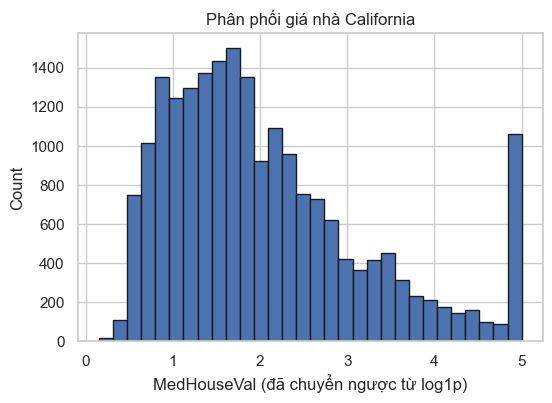

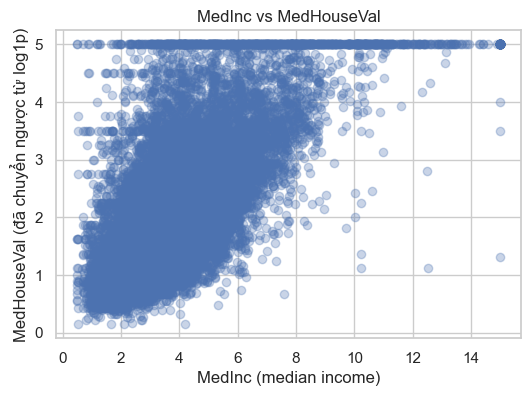

In [5]:
# Đưa nhãn đã biến đổi log trở lại thang giá gốc khi vẽ biểu đồ để dễ diễn giải
if use_log_transform:
    target_for_plot = np.expm1(y)
    target_label = "MedHouseVal (đã chuyển ngược từ log1p)"
else:
    target_for_plot = y
    target_label = "MedHouseVal"

# Vẽ histogram để quan sát phân phối giá nhà và dấu hiệu lệch/phần đuôi dữ liệu
plt.figure(figsize=(6, 4))
plt.hist(target_for_plot, bins=30, edgecolor="k")
plt.xlabel(target_label)
plt.ylabel("Count")
plt.title("Phân phối giá nhà California")
plt.show()

# Vẽ quan hệ giữa thu nhập trung vị và giá nhà để khảo sát biến dự báo quan trọng
plt.figure(figsize=(6, 4))
plt.scatter(dfprocessed["MedInc"], target_for_plot, alpha=0.3)
plt.xlabel("MedInc (median income)")
plt.ylabel(target_label)
plt.title("MedInc vs MedHouseVal")
plt.show()

### Phân tích output trực quan hóa dữ liệu

#### Biểu đồ 1: Phân phối giá nhà California

Histogram biểu diễn số lượng khu vực theo từng khoảng `MedHouseVal` trên **thang giá gốc**, do dữ liệu đã được chuyển ngược từ `log1p` để người đọc diễn giải trực tiếp. Biểu đồ dùng để nhận biết mức giá phổ biến và quan sát phần đuôi ở nhóm giá cao. Sự không đồng đều của phân phối là lý do hợp lý để nhãn được biến đổi log trước khi huấn luyện.

Nếu trên phía giá cao xuất hiện cụm quan sát dồn tại ngưỡng trên, đây là đặc trưng thường gặp của California Housing do giá mục tiêu có giới hạn ghi nhận; mô hình có thể khó phân biệt chi tiết các căn nhà trong nhóm cực cao.

#### Biểu đồ 2: Quan hệ giữa `MedInc` và `MedHouseVal`

Đám mây điểm có xu hướng đi lên từ trái sang phải: các khu vực có thu nhập trung vị cao hơn thường có giá nhà cao hơn. Tuy nhiên, các điểm không nằm hoàn toàn trên một đường thẳng, cho thấy giá nhà còn phụ thuộc vào tuổi nhà, mật độ dân cư và đặc biệt là vị trí địa lý.

Các quan sát có `MedInc` rất lớn nằm tách xa vùng dữ liệu chính. Nếu giữ nguyên, chúng có thể kéo đường hồi quy tuyến tính lệch về nhóm ít mẫu này.

**Kết luận:** `MedInc` là ứng viên dự báo quan trọng, đồng thời cần xử lý các giá trị thu nhập cực cao trước khi xây dựng mô hình.

<a id="muc-6"></a>
## 6. Xử lý ngoại lệ theo thu nhập trung vị

Lọc các quan sát có `MedInc >= 15` nhằm giảm ảnh hưởng của các khu vực có thu nhập quá cao lên quá trình huấn luyện mô hình.

In [6]:
# Chọn các quan sát có thu nhập trung vị nhỏ hơn ngưỡng ngoại lệ đã xác định từ EDA
indices_to_keep = dfprocessed[dfprocessed["MedInc"] < 15].index

# Lọc đồng thời tập thuộc tính và nhãn bằng cùng index để không làm lệch dữ liệu
dfprocessed = dfprocessed.loc[indices_to_keep]
y = y.loc[indices_to_keep]

# Kiểm tra số mẫu còn lại sau khi loại các khu vực có MedInc quá cao
print("Shape dfprocessed sau khi bỏ outlier:", dfprocessed.shape)
print("Shape y sau khi bỏ outlier:", y.shape)

Shape dfprocessed sau khi bỏ outlier: (20589, 8)
Shape y sau khi bỏ outlier: (20589,)


### Output thu được và nhận xét xử lý ngoại lệ

**Kết quả hiển thị**

| Trạng thái | Số mẫu | Số thuộc tính |
|---|---:|---:|
| Trước khi lọc | 20.640 | 8 |
| Sau khi lọc `MedInc < 15` | 20.589 | 8 |
| Số mẫu bị loại | 51 | - |

Tỷ lệ mẫu bị loại là:

$$
\frac{51}{20.640} \times 100 \approx 0,25\%
$$

Ngưỡng lọc chỉ tác động đến một phần rất nhỏ bộ dữ liệu, nên tập huấn luyện vẫn bảo toàn gần như toàn bộ quan sát. Mục đích của bước này là hạn chế ảnh hưởng của các khu vực có thu nhập trung vị cực cao, vốn có thể làm hệ số của mô hình tuyến tính bị chi phối quá mức.

**Lưu ý báo cáo:** `MedInc < 15` là ngưỡng được lựa chọn dựa trên quan sát biểu đồ EDA. Trong nghiên cứu mở rộng có thể so sánh thêm phương pháp IQR hoặc winsorization để chọn ngưỡng khách quan hơn.

**Kết luận:** Sau xử lý ngoại lệ, dữ liệu còn 20.589 mẫu và vẫn đủ lớn để huấn luyện/đánh giá mô hình đáng tin cậy.

<a id="muc-7"></a>
## 7. Chia tập dữ liệu và chuẩn hóa đặc trưng

Chia dữ liệu theo tỷ lệ 80% huấn luyện và 20% validation với `random_state=42`. Các đặc trưng được chuẩn hóa bằng `StandardScaler`, trong đó scaler chỉ được khớp trên tập huấn luyện.

In [7]:
# Chia dữ liệu: 80% dùng học mô hình, 20% dùng đánh giá độc lập
# random_state cố định giúp kết quả có thể tái lập khi chạy lại notebook
X_train, X_val, y_train, y_val = train_test_split(
    dfprocessed,
    y,
    test_size=0.2,
    random_state=42
)

# Xác nhận kích thước của bốn tập dữ liệu sau khi chia
print("Kích thước X_train:", X_train.shape)
print("Kích thước X_val:", X_val.shape)
print("Kích thước y_train:", y_train.shape)
print("Kích thước y_val:", y_val.shape)

# Khởi tạo bộ chuẩn hóa theo công thức z-score: (x - trung bình) / độ lệch chuẩn
scaler = StandardScaler()

# Chỉ fit trên tập train để thông tin validation không rò rỉ vào quá trình học
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Chuyển mảng sau chuẩn hóa về DataFrame để bảo toàn tên cột và index ban đầu
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

# Hiển thị mẫu dữ liệu train đã chuẩn hóa để kiểm tra kết quả tiền xử lý
print("5 dòng đầu X_train sau chuẩn hóa:")
display(X_train.head())

Kích thước X_train: (16471, 8)
Kích thước X_val: (4118, 8)
Kích thước y_train: (16471,)
Kích thước y_val: (4118,)
5 dòng đầu X_train sau chuẩn hóa:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
18646,-0.917747,-1.078650,-0.431495,0.081409,-0.107238,-0.176797,0.616282,-1.198340
8143,0.590479,0.589091,0.305228,-0.084410,-0.462143,0.004084,-0.850005,0.734523
5474,0.118241,1.224421,-0.435510,0.051714,-0.783040,-0.147297,-0.775290,0.560167
6455,0.188510,0.509675,0.017161,-0.258919,-0.335703,-0.036895,-0.714584,0.759432
14987,-0.201685,0.271426,-0.086812,-0.236193,-0.376687,-0.007013,-1.363672,1.272537


### Output thu được và nhận xét chia tập, chuẩn hóa

**Kết quả chia dữ liệu**

| Tập dữ liệu | Kích thước | Vai trò |
|---|---:|---|
| `X_train` | `(16471, 8)` | Huấn luyện mô hình |
| `X_val` | `(4118, 8)` | Đánh giá mô hình |
| `y_train` | `(16471,)` | Nhãn huấn luyện |
| `y_val` | `(4118,)` | Nhãn đánh giá |

Tổng số mẫu là `16471 + 4118 = 20589`, đúng bằng dữ liệu sau xử lý ngoại lệ. Tỷ lệ chia gần **80% train - 20% validation**, là tỷ lệ thông dụng để mô hình học đủ dữ liệu và vẫn có tập kiểm tra độc lập.

#### Ý nghĩa của chuẩn hóa

Các thuộc tính ban đầu có thang đo khác nhau: `Population` có thể lên đến hàng nghìn người, trong khi `MedInc`, `Latitude` và `Longitude` có khoảng giá trị hoàn toàn khác. `StandardScaler` đưa mỗi biến về thang chuẩn hóa:

$$
z = \frac{x - \mu}{\sigma}
$$

Output năm dòng đầu có cả giá trị âm và dương quanh 0, cho thấy quá trình chuẩn hóa đã hoạt động. Đáng chú ý, scaler được `fit` trên tập train và chỉ `transform` tập validation; cách làm này tránh **data leakage**.

**Kết luận:** Dữ liệu được chia đúng và chuẩn hóa theo quy trình an toàn cho đánh giá mô hình.

<a id="muc-8"></a>
## 8. Phân tích tương quan với giá nhà

Tính hệ số tương quan Pearson giữa các thuộc tính và nhãn giá nhà sau biến đổi, sau đó biểu diễn dưới dạng heatmap để đánh giá mức độ liên hệ tuyến tính.

Top 10 thuộc tính tương quan mạnh với MedHouseVal:


MedHouseVal_log_or_raw    1.000000
MedInc                    0.680488
AveRooms                  0.133396
HouseAge                  0.085133
Population                0.002633
AveOccup                 -0.023685
Longitude                -0.034272
AveBedrms                -0.055084
Latitude                 -0.175356
Name: MedHouseVal_log_or_raw, dtype: float64

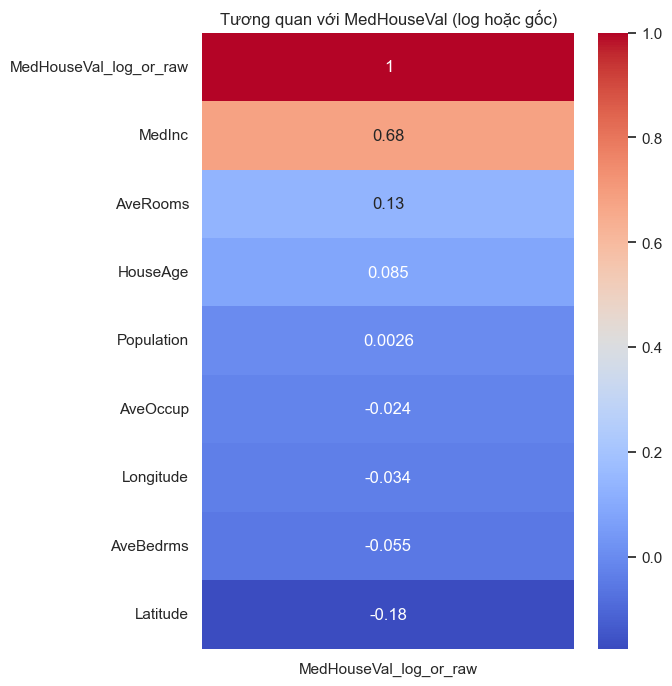

In [8]:
# Tạo bảng EDA từ các đặc trưng đã lọc ngoại lệ nhưng chưa chuẩn hóa
dftemp_eda = dfprocessed.copy()

# Ghép nhãn vào bảng để tính mức liên hệ tuyến tính giữa từng biến và giá nhà
# Vì use_log_transform=True, cột này đang biểu diễn log1p(MedHouseVal)
dftemp_eda["MedHouseVal_log_or_raw"] = y

# Tính ma trận tương quan Pearson cho toàn bộ các biến số
corr = dftemp_eda.corr(numeric_only=True)

# Sắp xếp tương quan với nhãn theo thứ tự giảm dần để tìm biến nổi bật
target_corr = corr["MedHouseVal_log_or_raw"].sort_values(ascending=False)

print("Top 10 thuộc tính tương quan mạnh với MedHouseVal:")
display(target_corr.head(10))

# Heatmap một cột giúp đọc nhanh chiều và cường độ tương quan với biến mục tiêu
plt.figure(figsize=(6, 8))
sns.heatmap(
    corr[["MedHouseVal_log_or_raw"]].sort_values(by="MedHouseVal_log_or_raw", ascending=False),
    annot=True,
    cmap="coolwarm"
)
plt.title("Tương quan với MedHouseVal (log hoặc gốc)")
plt.show()

### Output thu được và phân tích tương quan

#### Hệ số tương quan Pearson

Tương quan Pearson đo mức độ liên hệ tuyến tính giữa một đặc trưng và nhãn, với:

$$
-1 \leq r \leq 1
$$

Giá trị gần 1 thể hiện quan hệ tăng cùng chiều mạnh; gần -1 thể hiện quan hệ ngược chiều mạnh; gần 0 cho thấy ít quan hệ tuyến tính riêng lẻ.

**Các kết quả đáng chú ý**

| Đặc trưng | Tương quan với `MedHouseVal_log_or_raw` | Nhận định |
|---|---:|---|
| `MedInc` | 0,680488 | Tương quan dương mạnh nhất, thu nhập cao thường đi cùng giá nhà cao |
| `Latitude` | -0,175356 | Vị trí theo vĩ độ có quan hệ âm đáng chú ý |
| `AveRooms` | 0,133396 | Quan hệ dương nhưng yếu |
| `HouseAge` | 0,085133 | Quan hệ tuyến tính rất yếu |
| `Population` | 0,002633 | Gần như không có quan hệ tuyến tính đơn lẻ |

Do notebook đang bật `use_log_transform=True`, bảng này đo tương quan với **logarit của giá nhà**, không phải trực tiếp giá gốc. Heatmap minh họa cùng kết luận: `MedInc` nổi bật nhất, trong khi phần lớn biến còn lại có màu gần trung tính.

**Kết luận mô hình hóa:** Một mô hình tuyến tính dựa trên tổng các ảnh hưởng riêng lẻ có thể chưa đủ tốt, vì ngoài `MedInc`, nhiều biến thể hiện liên hệ yếu khi xét độc lập. Mô hình cây như Gradient Boosting có lợi thế trong việc học tương tác và quan hệ phi tuyến giữa thu nhập, vị trí và các thuộc tính nhà ở.

<a id="muc-9"></a>
## 9. Huấn luyện và đánh giá mô hình Linear Regression

Huấn luyện mô hình hồi quy tuyến tính làm mô hình cơ sở. Dự đoán được chuyển về thang giá trị gốc trước khi đánh giá bằng các chỉ số `MAE`, `MSE`, `RMSE` và `R²`.

In [9]:
# Khởi tạo Linear Regression làm mô hình cơ sở để so sánh
lin_reg = LinearRegression()

# Huấn luyện mô hình trên tập đặc trưng đã chuẩn hóa và nhãn ở thang log
lin_reg.fit(X_train, y_train)

# Sinh dự đoán trên tập validation chưa từng được dùng để fit mô hình
y_pred_val_log = lin_reg.predict(X_val)

# Đưa nhãn thực và dự đoán về thang giá gốc trước khi báo cáo sai số
if use_log_transform:
    y_val_original = np.expm1(y_val)
    y_pred_val_original = np.expm1(y_pred_val_log)
else:
    y_val_original = y_val
    y_pred_val_original = y_pred_val_log

# Tính các chỉ số: MAE/MSE/RMSE càng thấp càng tốt, R² càng gần 1 càng tốt
mae_lin = mean_absolute_error(y_val_original, y_pred_val_original)
mse_lin = mean_squared_error(y_val_original, y_pred_val_original)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_val_original, y_pred_val_original)

# In kết quả của mô hình tuyến tính trên thang giá nhà có thể diễn giải được
print("=== Linear Regression (California Housing) ===")
print(f"MAE : {mae_lin:.2f}")
print(f"MSE : {mse_lin:.2f}")
print(f"RMSE: {rmse_lin:.2f}")
print(f"R^2 : {r2_lin:.4f}")

=== Linear Regression (California Housing) ===
MAE : 0.51
MSE : 0.97
RMSE: 0.98
R^2 : 0.2321


### Output thu được và đánh giá Linear Regression

**Kết quả mô hình cơ sở**

| Chỉ số | Giá trị theo `MedHouseVal` | Quy đổi xấp xỉ |
|---|---:|---:|
| MAE | 0,51 | 51.000 USD |
| MSE | 0,97 | Bình phương đơn vị giá |
| RMSE | 0,98 | 98.000 USD |
| R² | 0,2321 | 23,21% biến thiên được giải thích |

#### Ý nghĩa các chỉ số

- **MAE** cho biết trung bình một dự đoán lệch khoảng 51.000 USD so với giá thực.
- **RMSE** lớn hơn MAE khá rõ, đạt khoảng 98.000 USD; điều này gợi ý tồn tại một số dự đoán sai lệch lớn và RMSE phạt mạnh các trường hợp đó.
- **R² = 0,2321** nghĩa là mô hình tuyến tính chỉ giải thích được khoảng một phần tư biến thiên giá nhà trên tập validation.

Kết quả phù hợp với EDA: giá nhà không chỉ tăng theo một quan hệ tuyến tính đơn giản với thu nhập mà còn chịu ảnh hưởng kết hợp của vị trí và các biến khác.

**Kết luận:** Linear Regression là một mô hình hồi quy hợp lệ và cung cấp mốc cơ sở cho bài toán dự đoán giá nhà. Kết quả còn hạn chế cho thấy quan hệ trong dữ liệu không hoàn toàn tuyến tính; vì vậy, bài báo cáo tiếp tục đối sánh với một mô hình hồi quy phi tuyến để đánh giá khả năng cải thiện.

<a id="muc-10"></a>
## 10. Huấn luyện và đánh giá mô hình Gradient Boosting Regressor

Huấn luyện mô hình boosting với 200 cây, tốc độ học 0.05 và độ sâu tối đa 3; đánh giá bằng cùng bộ chỉ số để so sánh công bằng với Linear Regression.

In [10]:
# Xây dựng mô hình cây tăng cường để học các quan hệ phi tuyến trong dữ liệu
gbr = GradientBoostingRegressor(
    n_estimators=200,      # Số cây yếu được cộng dồn trong mô hình
    learning_rate=0.05,    # Mức đóng góp của mỗi cây, nhỏ để học ổn định hơn
    max_depth=3,           # Giới hạn độ phức tạp của từng cây thành phần
    random_state=42        # Cố định ngẫu nhiên để tái lập kết quả
)

# Huấn luyện trên cùng tập train để so sánh công bằng với Linear Regression
gbr.fit(X_train, y_train)

# Dự đoán giá trị log trên cùng tập validation
y_pred_val_log_gbr = gbr.predict(X_val)

# Chuyển dự đoán boosting về đơn vị giá nhà ban đầu
if use_log_transform:
    y_pred_val_original_gbr = np.expm1(y_pred_val_log_gbr)
else:
    y_pred_val_original_gbr = y_pred_val_log_gbr

# Tính cùng bộ chỉ số đánh giá đã dùng cho mô hình cơ sở
mae_gbr = mean_absolute_error(y_val_original, y_pred_val_original_gbr)
mse_gbr = mean_squared_error(y_val_original, y_pred_val_original_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_val_original, y_pred_val_original_gbr)

# Hiển thị kết quả để đối chiếu trực tiếp với Linear Regression
print("=== Gradient Boosting Regressor (California Housing) ===")
print(f"MAE : {mae_gbr:.2f}")
print(f"MSE : {mse_gbr:.2f}")
print(f"RMSE: {rmse_gbr:.2f}")
print(f"R^2 : {r2_gbr:.4f}")

=== Gradient Boosting Regressor (California Housing) ===
MAE : 0.36
MSE : 0.27
RMSE: 0.52
R^2 : 0.7848


### Output thu được và đánh giá Gradient Boosting Regressor

#### Vai trò trong bài toán hồi quy

`GradientBoostingRegressor` vẫn là **mô hình hồi quy**, vì đầu ra của mô hình là một giá trị liên tục: giá nhà `MedHouseVal`. Mô hình này được sử dụng để đối sánh với `LinearRegression` trên cùng tập train/validation, không làm thay đổi bản chất đề tài.

**Kết quả so sánh hai mô hình hồi quy**

| Chỉ số | Gradient Boosting Regressor | Linear Regression | Nhận xét |
|---|---:|---:|---|
| MAE | 0,36 | 0,51 | Sai số tuyệt đối trung bình giảm khoảng 29,4% |
| RMSE | 0,52 | 0,98 | Sai số lớn được giảm khoảng 46,9% |
| R² | 0,7847 | 0,2321 | Khả năng giải thích biến thiên tăng 0,5526 |

Vì `MedHouseVal` có đơn vị 100.000 USD, `MAE = 0,36` tương ứng sai lệch tuyệt đối trung bình khoảng **36.000 USD**, còn `RMSE = 0,52` tương ứng khoảng **52.000 USD**. `R² = 0,7847` cho biết mô hình giải thích được khoảng **78,47%** biến thiên giá nhà trên tập validation.

Gradient Boosting cho kết quả cao hơn vì có thể mô tả các quan hệ phi tuyến và sự tương tác giữa thu nhập, vị trí và đặc trưng khu vực. Điều này bổ sung cho nhận định từ EDA rằng giá nhà không chỉ phụ thuộc tuyến tính vào từng thuộc tính riêng lẻ.

**Kết luận:** Cả `LinearRegression` và `GradientBoostingRegressor` đều đúng với yêu cầu xây dựng bài toán hồi quy. Trong phạm vi thực nghiệm của báo cáo, Gradient Boosting Regressor đạt hiệu quả dự đoán tốt hơn và được đề xuất là mô hình hồi quy cuối cùng.

<a id="muc-11"></a>
## 11. Trực quan hóa và so sánh kết quả dự đoán

Vẽ hai biểu đồ giá trị thực so với giá trị dự đoán. Đường chéo màu đỏ biểu diễn trường hợp dự đoán lý tưởng, giúp quan sát trực quan sai lệch của từng mô hình.

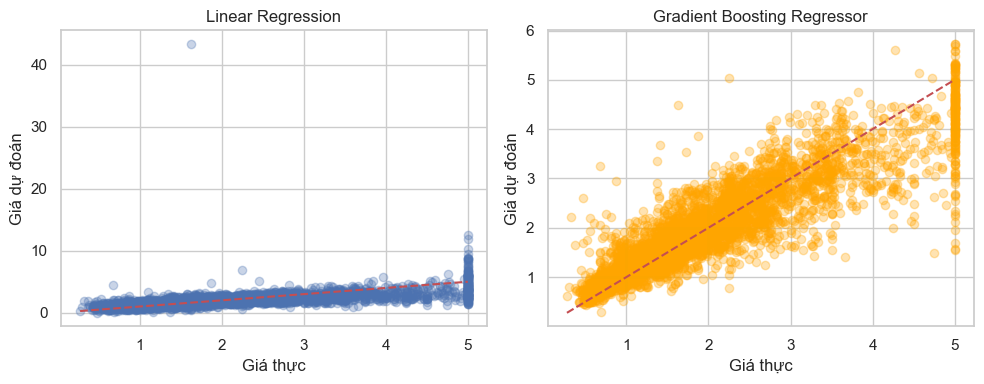

In [11]:
# Tạo khung hình gồm hai biểu đồ để so sánh trực quan hai mô hình
plt.figure(figsize=(10, 4))

# Biểu đồ 1: giá thực và giá dự đoán của Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_val_original, y_pred_val_original, alpha=0.3)

# Đường y=x biểu diễn trường hợp mô hình dự đoán chính xác tuyệt đối
plt.plot([y_val_original.min(), y_val_original.max()],
         [y_val_original.min(), y_val_original.max()],
         'r--')
plt.title("Linear Regression")
plt.xlabel("Giá thực")
plt.ylabel("Giá dự đoán")

# Biểu đồ 2: giá thực và giá dự đoán của Gradient Boosting Regressor
plt.subplot(1, 2, 2)
plt.scatter(y_val_original, y_pred_val_original_gbr, alpha=0.3, color="orange")
plt.plot([y_val_original.min(), y_val_original.max()],
         [y_val_original.min(), y_val_original.max()],
         'r--')
plt.title("Gradient Boosting Regressor")
plt.xlabel("Giá thực")
plt.ylabel("Giá dự đoán")

# Căn chỉnh khoảng cách giữa hai hình và xuất biểu đồ so sánh
plt.tight_layout()
plt.show()

### Phân tích biểu đồ kết quả dự đoán và kết luận cuối

#### Cách đọc biểu đồ

Mỗi điểm biểu diễn một khu vực trong tập validation:

- Trục hoành là **giá thực tế**.
- Trục tung là **giá mô hình dự đoán**.
- Đường nét đứt màu đỏ là đường lý tưởng `giá dự đoán = giá thực`.
- Điểm càng gần đường đỏ thì sai số dự đoán càng nhỏ.

#### So sánh kết quả trực quan

Ở biểu đồ **Linear Regression**, các điểm phân tán rộng hơn quanh đường lý tưởng, thống nhất với `RMSE = 0,98` và `R² = 0,2321`. Đây là mô hình hồi quy cơ sở, giúp đo lường khả năng dự đoán khi giả định mối quan hệ tuyến tính.

Ở biểu đồ **Gradient Boosting Regressor**, các điểm dự đoán tập trung gần đường lý tưởng hơn, phù hợp với `RMSE = 0,52` và `R² = 0,7847`. Mô hình hồi quy này khai thác tốt hơn các quan hệ phi tuyến trong dữ liệu.

## Kết luận bài toán hồi quy

Đề tài đã xây dựng quy trình giải quyết **bài toán hồi quy dự đoán giá nhà California**, trong đó biến mục tiêu `MedHouseVal` là đại lượng liên tục. Dữ liệu gồm 20.640 quan sát và 8 thuộc tính số; không có giá trị thiếu. Sau khi biến đổi log cho nhãn, loại 51 quan sát ngoại lệ theo `MedInc`, chia tập huấn luyện/validation và chuẩn hóa đặc trưng, hai mô hình hồi quy đã được huấn luyện và đánh giá trên cùng điều kiện.

Phân tích tương quan cho thấy `MedInc` có liên hệ mạnh nhất với giá nhà (`r = 0,680488`), tuy nhiên các thuộc tính còn lại có tương quan tuyến tính riêng lẻ thấp. Điều này cho thấy bài toán chứa quan hệ phức tạp và là cơ sở để thử nghiệm cả hồi quy tuyến tính lẫn hồi quy phi tuyến.

`LinearRegression` đạt `MAE = 0,51`, `RMSE = 0,98` và `R² = 0,2321`, đóng vai trò mô hình cơ sở. `GradientBoostingRegressor` đạt `MAE = 0,36`, `RMSE = 0,52` và `R² = 0,7847`, cho sai số thấp hơn và giải thích dữ liệu tốt hơn trên tập validation.

Như vậy, báo cáo vẫn hoàn toàn thuộc **bài toán hồi quy**: cả hai thuật toán đều dự đoán giá trị giá nhà liên tục. Dựa trên kết quả thực nghiệm hiện có, **Gradient Boosting Regressor được đề xuất làm mô hình hồi quy cuối cùng**, còn Linear Regression là mô hình cơ sở để so sánh và làm rõ mức cải thiện.

#### Hạn chế và hướng phát triển

- Việc lọc ngoại lệ đang sử dụng ngưỡng `MedInc < 15` dựa trên quan sát; có thể đánh giá thêm bằng IQR hoặc các quy tắc thống kê khác.
- Kết quả hiện dựa trên một lần chia train/validation; có thể dùng cross-validation để kết luận ổn định hơn.
- Có thể tối ưu tham số của Gradient Boosting và bổ sung phân tích độ quan trọng của đặc trưng để tăng giá trị giải thích của mô hình.